# Methods for minimizing a function

### Dihotomic method

In [11]:
function dihotomic(f, a, b, eps, delta, max_iters = 1000000)
  i = 0
  while i < max_iters && abs(b - a) > eps
    lambda = (a + b) / 2 - delta
    mu = (a + b) / 2 + delta
    if f(lambda) < f(mu)
      b = mu
    else
      a = lambda
    end
    i += 1
  end

  if abs(b - a) < eps
    res = (a + b) / 2
    return a, b, res, f(res)
  else
    error("Maximum iterations reached without convergence.")
  end
end

dihotomic (generic function with 2 methods)

### Binary search on derivative of concave function

In [12]:
# Binary search for point where df/dx = 0
function dx_bs_min(f, a, b, eps, dx_eps, max_iters = 1000000)
  left = a
  right = b
  
  while(right - left) > eps && max_iters > 0
    mid = (left + right) / 2.0
    df = f(mid) - f(mid - dx_eps)
    
    if df < 0
      left = mid
    else
      right = mid
    end

    max_iters -= 1
  end
  
  res = (left + right) / 2.0
  return left, right, res, f(res)
end

dx_bs_min (generic function with 2 methods)

### Golden section method

In [13]:
function golden_section(f, a, b, eps, alpha, max_iters = 1000000)
  lambda = a + (1 - alpha) * (b - a)
  mu = a + alpha * (b - a)
  f_lambda = f(lambda)
  f_mu = f(mu)

  while abs(b - a) > eps && max_iters > 0
    if f_lambda >= f_mu
      a = lambda
      lambda = mu
      f_lambda = f_mu
      mu = a + alpha * (b - a)
      f_mu = f(mu)
    else
      b = mu
      mu = lambda
      f_mu = f_lambda
      lambda = a + (1 - alpha) * (b - a)
      f_lambda = f(lambda)
    end

    max_iters -= 1
  end

  res = (a + b) / 2.0
  return a, b, res, f(res)
end

golden_section (generic function with 2 methods)

### Comparison and plotting of all methods

In [23]:
using Plots
using Printf
using BenchmarkTools

function calculate_min(f, a, b, eps = 1e-4)
  dh_a, dh_b, dh_min, dh_f_min = dihotomic(f, a, b, eps, 1e-6)
  bs_a, bs_b, bs_min, bs_f_min = dx_bs_min(f, a, b, eps, 1e-8)
  gm_a, gm_b, gm_min, gm_f_min = golden_section(f, a, b, eps, (sqrt(5) - 1) / 2)

  @printf("Dihotomic method: ")
  @btime dihotomic($f, $a, $b, $eps, 1e-6)
  @printf("Minimum found in the interval: [%.4f, %.4f]\n", dh_a, dh_b)
  @printf("With x ~= %.4f and f(x) min ~= %.4f\n", dh_min, dh_f_min)
  
  @printf("\nBinary search method: ")
  @btime dx_bs_min($f, $a, $b, $eps, 1e-8)
  @printf("Minimum found in the interval: [%.4f, %.4f]\n", bs_a, bs_b)
  @printf("With x ~= %.4f and f(x) min ~= %.4f\n", bs_min, bs_f_min)

  @printf("\nGolden Section method: ")
  @btime golden_section($f, $a, $b, $eps, (sqrt(5) - 1) / 2)
  @printf("Minimum found in the interval: [%.4f, %.4f]\n", gm_a, gm_b)
  @printf("With x ~= %.4f and f(x) min ~= %.4f\n", gm_min, gm_f_min)

  # Plot the function and mark the findings
  x = a:0.01:b
  y = f.(x)
  p = plot(x, y, label="f(x)", xlabel="x", ylabel="f(x)")

  annotate!(p, a, maximum(y), text(" Min: $(round(gm_f_min, digits=4)) at x ≈ $(round(gm_min, digits=4))", :left, 10))
  
  return p
end

calculate_min (generic function with 2 methods)

### Results for different functions and intervals


----------------------------------------
EVALUATING: f(x) = x⁴ + x³ + 5x² + x + 2
----------------------------------------
Dihotomic method:   466.304 ns (0 allocations: 0 bytes)
Minimum found in the interval: [-0.1055, -0.0996]
With x ~= -0.1025 and f(x) min ~= 1.9491

Binary search method:   322.205 ns (0 allocations: 0 bytes)
Minimum found in the interval: [-0.1055, -0.0996]
With x ~= -0.1025 and f(x) min ~= 1.9491

Golden Section method:   111.205 ns (0 allocations: 0 bytes)
Minimum found in the interval: [-0.1069, -0.0998]
With x ~= -0.1033 and f(x) min ~= 1.9491

----------------------------------------
EVALUATING: f(x) = 5x² + x + 16
----------------------------------------
Dihotomic method:   65.559 ns (0 allocations: 0 bytes)
Minimum found in the interval: [-0.1016, -0.0937]
With x ~= -0.0977 and f(x) min ~= 15.9500

Binary search method:   66.773 ns (0 allocations: 0 bytes)
Minimum found in the interval: [-0.1016, -0.0938]
With x ~= -0.0977 and f(x) min ~= 15.9500

Golden Se

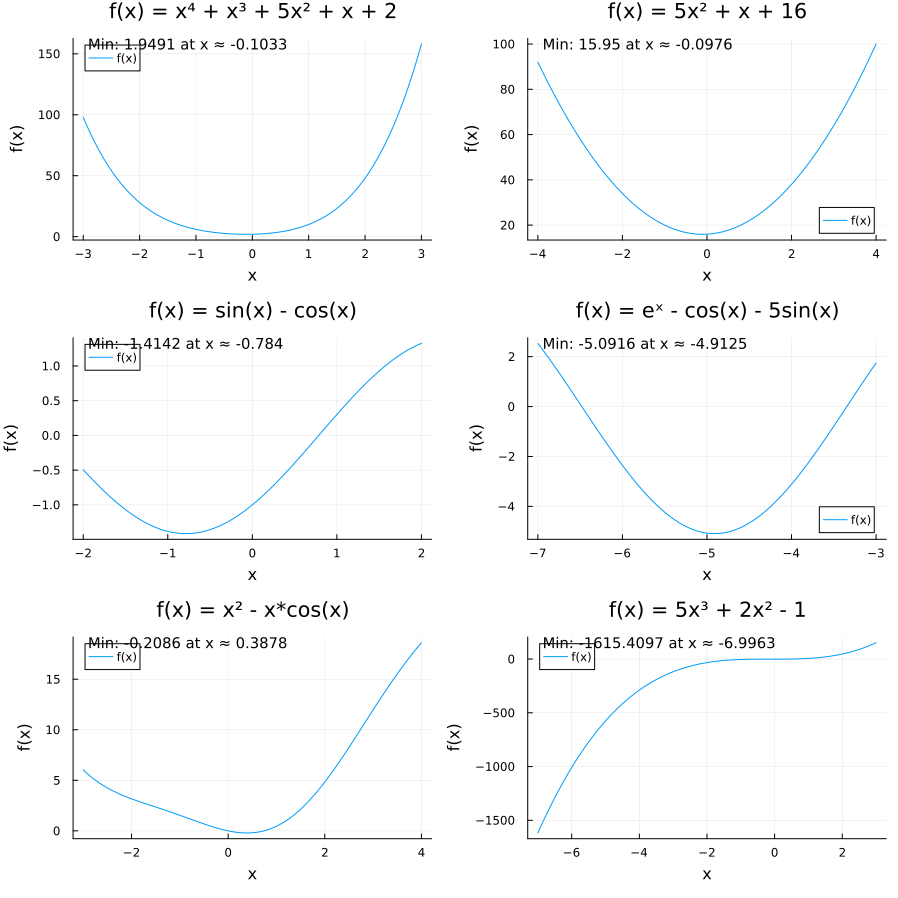

In [29]:
functions = [
  (name="f(x) = x⁴ + x³ + 5x² + x + 2",   f = x -> x^4 + x^3 + 5x^2 + x + 2,     a = -3.0, b = 3.0),
  (name="f(x) = 5x² + x + 16",            f = x -> 5x^2 + x + 16,                a = -4.0, b = 4.0),
  (name="f(x) = sin(x) - cos(x)",         f = x -> sin(x) - cos(x),              a = -2.0, b = 2.0),
  (name="f(x) = eˣ - cos(x) - 5sin(x)",   f = x -> exp(x) - cos(x) - 5sin(x),    a = -7.0, b = -3.0),
  (name="f(x) = x² - x*cos(x)",           f = x -> x^2 - x*cos(x),               a = -3.0, b = 4.0),
  (name="f(x) = 5x³ + 2x² - 1",           f = x -> 5x^3 + 2x^2 - 1,              a = -7.0, b = 3.0)
]

all_plots = []

for fn in functions
  println("\n" * "-"^40)
  println("EVALUATING: $(fn.name)")
  println("-"^40)
  
  p = calculate_min(fn.f, fn.a, fn.b, 1e-2)
  
  title!(p, fn.name) 
  
  push!(all_plots, p)
end

n_cols = 2
n_rows = ceil(Int, length(functions) / n_cols)

plot(all_plots..., layout=(n_rows, n_cols), size=(900, 300 * n_rows))